# Exploratory Data Analysis — SST / ENSO Indices vs Dengue Outbreaks

**Scope:** investigate whether large-scale ENSO climate variability (El Niño / La Niña) explains
the timing and magnitude of dengue epidemics in the four Southeast Brazilian capitals.

**Key observation driving this analysis:** the 2024 dengue season was historically unprecedented in
size — the only remotely comparable outbreak was in 2016 and partly in 2012. El Niño events of 2015–16
and 2023–24 coincided with both. This notebook tests that hypothesis quantitatively.

**Datasets**
- `sst_indices.csv` — monthly Niño 1+2, Niño 3, Niño 3.4, Niño 4 SSTs and anomalies (NOAA CPC, 1982–2025)
- `RONI_nino_3_4.csv` — Relative Oceanic Niño Index, overlapping 3-month seasons (NOAA CPC, 1950–2026)
- `infodengue_capitals_subsetBR.csv` — weekly dengue incidence for Vitória, BH, RJ, SP (InfoDengue)

**Sections**
1. Load & inspect SST data
2. Load & parse RONI (seasonal → monthly)
3. Merge into a unified monthly ENSO time series
4. ENSO event classification (El Niño / La Niña)
5. Load dengue data & aggregate monthly
6. Merge dengue with ENSO
7. Epidemic spotlight: 2024 mega-outbreak vs historical context
8. ENSO conditions during major outbreaks
9. Lagged cross-correlation: ENSO indices → dengue incidence
10. Feature engineering: lagged ENSO candidate predictors
11. Collinearity diagnostics
12. Summary of findings

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy import stats

DATA_DIR  = Path("../data/raw")
SST_PATH  = DATA_DIR / "sst_indices.csv"
RONI_PATH = DATA_DIR / "RONI_nino_3_4.csv"
DENGUE_PATH = DATA_DIR / "infodengue_capitals_subsetBR.csv"

FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "font.size": 10})

CITY_COLORS = {
    "Vitória":          "#1b9e77",
    "Belo Horizonte":   "#d95f02",
    "Rio de Janeiro":   "#7570b3",
    "São Paulo":        "#e7298a",
}

ENSO_COLORS = {
    "El Niño": "#d73027",
    "La Niña": "#4575b4",
}

def save_fig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## 1. Load & inspect SST data

In [2]:
sst_raw = pd.read_csv(SST_PATH)
sst_raw.columns = [
    "year", "month",
    "Nino12", "Nino12_anom",
    "Nino3",  "Nino3_anom",
    "Nino4",  "Nino4_anom",
    "Nino34", "Nino34_anom",
]
sst_raw["date"] = pd.to_datetime(sst_raw[["year", "month"]].assign(day=1))
print(sst_raw.shape)
sst_raw.head()

(528, 11)


,year,month,Nino12,Nino12_anom,Nino3,Nino3_anom,Nino4,Nino4_anom,Nino34,Nino34_anom,date
0,1982,1,24.28,-0.24,25.84,0.17,28.01,-0.21,26.65,0.08,1982-01-01
1,1982,2,25.38,-0.72,26.26,-0.11,27.99,-0.11,26.54,-0.20,1982-02-01
2,1982,3,25.22,-1.38,26.92,-0.25,28.18,-0.05,27.09,-0.14,1982-03-01
3,1982,4,24.57,-1.16,27.52,-0.05,28.61,0.10,27.83,0.02,1982-04-01
4,1982,5,24.00,-0.62,27.70,0.49,29.19,0.40,28.37,0.49,1982-05-01


In [3]:
print(f"Date range: {sst_raw.date.min().date()}  →  {sst_raw.date.max().date()}")
sst_raw[["Nino12_anom", "Nino3_anom", "Nino4_anom", "Nino34_anom"]].describe()

Date range: 1982-01-01  →  2025-12-01


,Nino12_anom,Nino3_anom,Nino4_anom,Nino34_anom
count,528.000000,528.000000,528.000000,528.000000
mean,-0.014167,-0.036212,-0.074280,-0.055398
std,1.062135,0.866706,0.644221,0.837374
min,-1.900000,-2.160000,-1.870000,-2.220000
25%,-0.720000,-0.632500,-0.552500,-0.642500
50%,-0.205000,-0.135000,0.000000,-0.110000
75%,0.470000,0.445000,0.390000,0.450000
max,4.030000,3.070000,1.550000,2.720000


## 2. Load & parse RONI (seasonal → monthly)

RONI is reported in overlapping 3-month seasons (DJF, JFM, …, NDJ). Each label is mapped to
the **centre month** of the season so it can be joined with the monthly SST time series:

| Season | Centre month |
|--------|-------------|
| DJF    | January (1) |
| JFM    | February (2)|
| …      | …           |
| NDJ    | December (12)|

The `YR` column in the RONI file refers to the year of the centre month for all seasons
(NOAA CPC convention).

In [4]:
SEAS_TO_MONTH = {
    "DJF": 1, "JFM": 2, "FMA": 3, "MAM": 4,
    "AMJ": 5, "MJJ": 6, "JJA": 7, "JAS": 8,
    "ASO": 9, "SON": 10, "OND": 11, "NDJ": 12,
}

roni_raw = pd.read_csv(RONI_PATH)
roni_raw.columns = ["season", "year", "RONI"]
roni_raw["month"] = roni_raw["season"].map(SEAS_TO_MONTH)
roni_raw["date"]  = pd.to_datetime(roni_raw[["year", "month"]].assign(day=1))
roni_raw = roni_raw.sort_values("date").reset_index(drop=True)

print(f"Date range: {roni_raw.date.min().date()}  →  {roni_raw.date.max().date()}")
roni_raw.head(14)

Date range: 1950-01-01  →  2026-04-01


,season,year,RONI,month,date
0,DJF,1950,-1.47,1,1950-01-01
1,JFM,1950,-1.27,2,1950-02-01
2,FMA,1950,-1.11,3,1950-03-01
3,MAM,1950,-1.09,4,1950-04-01
4,AMJ,1950,-1.00,5,1950-05-01
5,MJJ,1950,-0.71,6,1950-06-01
6,JJA,1950,-0.41,7,1950-07-01
7,JAS,1950,-0.24,8,1950-08-01
8,ASO,1950,-0.22,9,1950-09-01
9,SON,1950,-0.29,10,1950-10-01


## 3. Merge into a unified monthly ENSO time series

In [5]:
enso = sst_raw.merge(
    roni_raw[["date", "RONI"]],
    on="date",
    how="left",
)
enso = enso.sort_values("date").reset_index(drop=True)

print(f"Merged ENSO shape: {enso.shape}")
print(f"Missing RONI:      {enso.RONI.isna().sum()} rows")
enso[["date", "Nino34_anom", "Nino4_anom", "RONI"]].tail()

Merged ENSO shape: (528, 12)
Missing RONI:      0 rows


,date,Nino34_anom,Nino4_anom,RONI
523,2025-08-01,-0.33,-0.06,-0.63
524,2025-09-01,-0.44,-0.27,-0.77
525,2025-10-01,-0.48,-0.33,-0.87
526,2025-11-01,-0.68,-0.52,-0.93
527,2025-12-01,-0.61,-0.23,-0.97


## 4. ENSO event classification (El Niño / La Niña)

The official NOAA definition requires **five consecutive overlapping 3-month RONI anomalies** ≥ +0.5 °C
(El Niño) or ≤ −0.5 °C (La Niña).  We implement this as a 5-season rolling check on the monthly RONI
series.

In [6]:
THRESHOLD = 0.5
MIN_CONSEC = 5          # consecutive overlapping 3-month seasons

# rolling flag: all 5 months in the window must exceed the threshold
enso["el_nino_flag"] = (
    enso["RONI"]
    .rolling(MIN_CONSEC, min_periods=MIN_CONSEC)
    .apply(lambda x: (x >= THRESHOLD).all())
    .fillna(0)
    .astype(bool)
)
enso["la_nina_flag"] = (
    enso["RONI"]
    .rolling(MIN_CONSEC, min_periods=MIN_CONSEC)
    .apply(lambda x: (x <= -THRESHOLD).all())
    .fillna(0)
    .astype(bool)
)

print("El Niño months:", enso.el_nino_flag.sum())
print("La Niña months:", enso.la_nina_flag.sum())

El Niño months: 82
La Niña months: 112


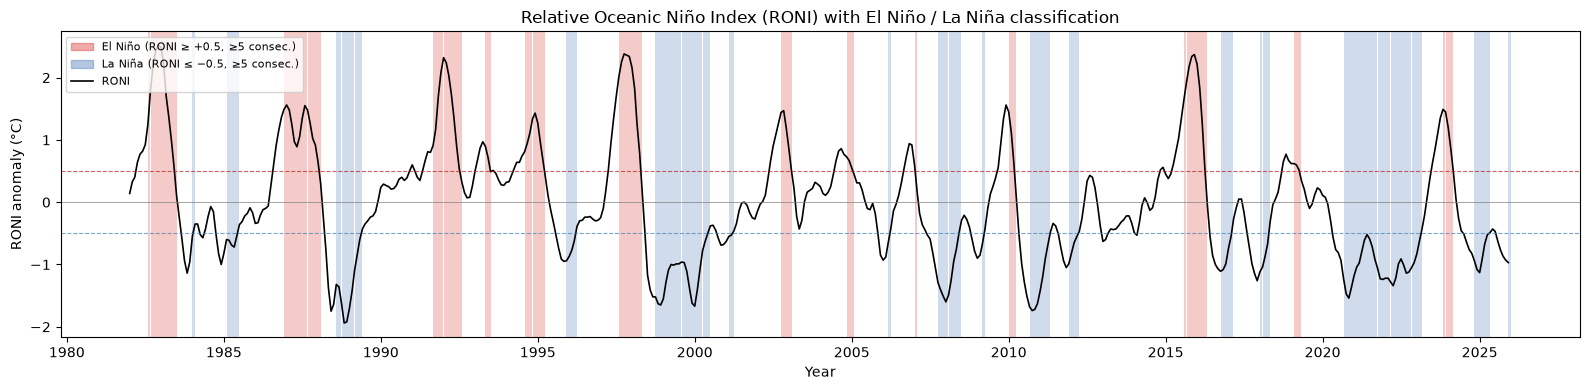

In [7]:
fig, ax = plt.subplots(figsize=(16, 4))

# shade El Niño / La Niña periods
for _, row in enso.iterrows():
    if row["el_nino_flag"]:
        ax.axvspan(row["date"], row["date"] + pd.offsets.MonthEnd(1),
                   color=ENSO_COLORS["El Niño"], alpha=0.25, lw=0)
    if row["la_nina_flag"]:
        ax.axvspan(row["date"], row["date"] + pd.offsets.MonthEnd(1),
                   color=ENSO_COLORS["La Niña"], alpha=0.25, lw=0)

ax.plot(enso["date"], enso["RONI"], color="black", lw=1.2, label="RONI")
ax.axhline( THRESHOLD, color="firebrick", ls="--", lw=0.8, alpha=0.7)
ax.axhline(-THRESHOLD, color="steelblue",  ls="--", lw=0.8, alpha=0.7)
ax.axhline(0, color="grey", lw=0.5)

legend_patches = [
    mpatches.Patch(color=ENSO_COLORS["El Niño"], alpha=0.4, label="El Niño (RONI ≥ +0.5, ≥5 consec.)"),
    mpatches.Patch(color=ENSO_COLORS["La Niña"], alpha=0.4, label="La Niña (RONI ≤ −0.5, ≥5 consec.)"),
    mlines.Line2D([], [], color="black", lw=1.2, label="RONI"),
]
ax.legend(handles=legend_patches, loc="upper left", fontsize=8)
ax.set_title("Relative Oceanic Niño Index (RONI) with El Niño / La Niña classification")
ax.set_ylabel("RONI anomaly (°C)")
ax.set_xlabel("Year")
fig.tight_layout()
save_fig(fig, "11_roni_classification")

## 5. Load dengue data & aggregate monthly

In [8]:
deng = pd.read_csv(DENGUE_PATH, parse_dates=["data_iniSE"])
deng = deng.rename(columns={"data_iniSE": "week_date"})

# Assign calendar year and month from the epidemiological week start date
deng["year"]  = deng["week_date"].dt.year
deng["month"] = deng["week_date"].dt.month

# Monthly aggregation: sum estimated cases, mean incidence per 100k, mean population
monthly_city = (
    deng.groupby(["city_name", "year", "month"])
    .agg(
        casos_est   = ("casos_est",  "sum"),
        p_inc100k   = ("p_inc100k",  "mean"),
        pop         = ("pop",        "mean"),
    )
    .reset_index()
)
monthly_city["date"] = pd.to_datetime(monthly_city[["year", "month"]].assign(day=1))

# Brazil-wide monthly aggregate (sum across cities, then recompute incidence)
monthly_br = (
    monthly_city.groupby(["year", "month", "date"])
    .agg(casos_est=("casos_est", "sum"), pop=("pop", "sum"))
    .reset_index()
)
monthly_br["p_inc100k"] = monthly_br["casos_est"] / monthly_br["pop"] * 1e5

print("Monthly city shape:", monthly_city.shape)
print("Monthly Brazil shape:", monthly_br.shape)
monthly_br.tail()

Monthly city shape: (792, 7)
Monthly Brazil shape: (198, 6)


,year,month,date,casos_est,pop,p_inc100k
193,2026,2,2026-02-01,22800.0,21550492.0,105.798049
194,2026,3,2026-03-01,32565.0,21550492.0,151.110239
195,2026,4,2026-04-01,21984.0,21550492.0,102.011592
196,2026,5,2026-05-01,18124.0,21550492.0,84.100168
197,2026,6,2026-06-01,2873.5,21550492.0,13.333802


## 6. Merge dengue with ENSO

In [9]:
enso_cols = ["date", "Nino34_anom", "Nino4_anom", "Nino3_anom", "RONI",
             "el_nino_flag", "la_nina_flag"]

# Brazil-wide merged
df_br = monthly_br.merge(enso[enso_cols], on="date", how="left")

# Per-city merged
df_city = monthly_city.merge(enso[enso_cols], on="date", how="left")

print("Missing ENSO in dengue window:", df_br["RONI"].isna().sum())
df_br[["date", "casos_est", "p_inc100k", "Nino34_anom", "RONI"]].tail()

Missing ENSO in dengue window: 6


,date,casos_est,p_inc100k,Nino34_anom,RONI
193,2026-02-01,22800.0,105.798049,NaN,NaN
194,2026-03-01,32565.0,151.110239,NaN,NaN
195,2026-04-01,21984.0,102.011592,NaN,NaN
196,2026-05-01,18124.0,84.100168,NaN,NaN
197,2026-06-01,2873.5,13.333802,NaN,NaN


## 7. Epidemic spotlight: the 2024 mega-outbreak vs historical context

Annual case totals across all four cities to put the 2024 epidemic in perspective.

In [10]:
annual_br = (
    df_br.groupby("year")
    .agg(casos_total=("casos_est", "sum"))
    .reset_index()
)

# Classify ENSO by the pre-epidemic window: Aug–Dec of the PRIOR calendar year.
# Dengue epidemics peak in Q1 (Jan–Apr); the ~4-month lag means the Aug–Dec
# RONI of the preceding year is the climatically relevant signal.
def pre_epidemic_enso(epidemic_year):
    prior = enso[
        (enso["date"].dt.year == epidemic_year - 1) &
        (enso["date"].dt.month >= 8)
    ]["RONI"]
    if prior.empty:
        return "Neutral", np.nan
    mean_roni = prior.mean()
    if mean_roni >= 0.5:
        return "El Niño", mean_roni
    if mean_roni <= -0.5:
        return "La Niña", mean_roni
    return "Neutral", mean_roni

annual_br[["pre_enso_phase", "pre_roni"]] = [
    pre_epidemic_enso(y) for y in annual_br["year"]
]
# Also keep the within-year mean for reference
annual_enso_yr = (
    enso.groupby(enso["date"].dt.year)
    .agg(roni_mean=("RONI", "mean"))
    .reset_index()
    .rename(columns={"date": "year"})
)
annual = annual_br.merge(annual_enso_yr, on="year", how="left")
annual


,year,casos_total,pre_enso_phase,pre_roni,roni_mean
0,2010,103414.0,El Niño,0.958,-0.652500
1,2011,118839.0,La Niña,-1.656,-0.805000
2,2012,209332.0,La Niña,-0.846,-0.148333
3,2013,248550.0,Neutral,0.124,-0.398333
4,2014,84217.0,Neutral,-0.274,-0.003333
5,2015,147372.0,Neutral,0.286,1.294167
6,2016,243085.0,El Niño,2.092,-0.070833
7,2017,28419.0,La Niña,-1.05,-0.525000
8,2018,28237.0,La Niña,-0.918,-0.113333
9,2019,235751.0,El Niño,0.53,0.280000


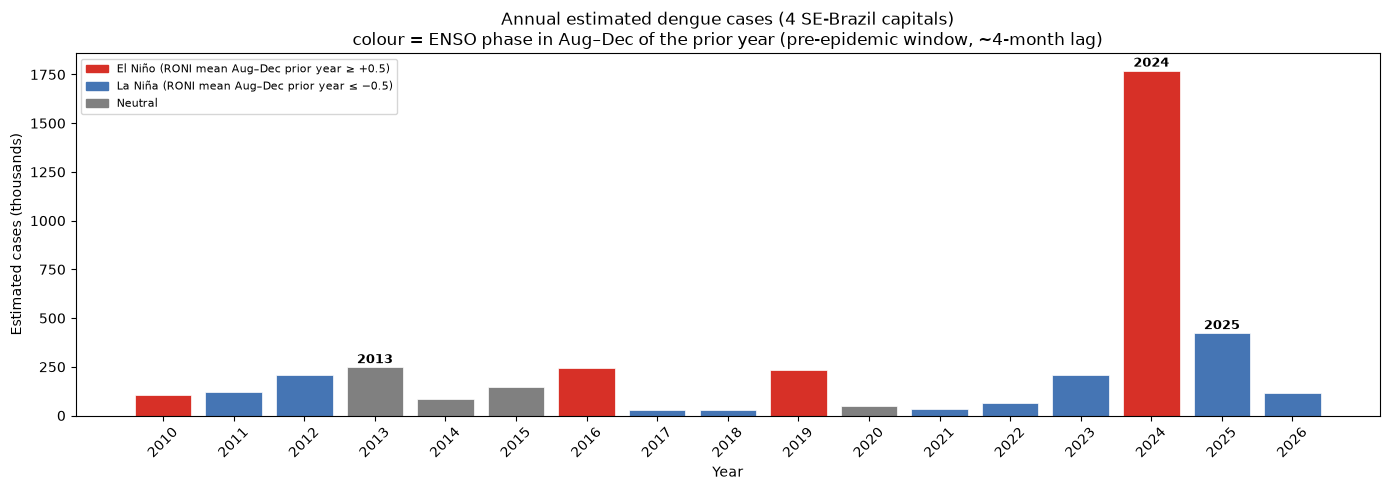

In [11]:
phase_palette = {"El Niño": ENSO_COLORS["El Niño"], "La Niña": ENSO_COLORS["La Niña"], "Neutral": "#808080"}
bar_colors = annual["pre_enso_phase"].map(phase_palette)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(annual["year"], annual["casos_total"] / 1e3,
       color=bar_colors, edgecolor="white", lw=0.5)

# annotate the top-3 years
for _, row in annual.nlargest(3, "casos_total").iterrows():
    ax.text(row["year"], row["casos_total"] / 1e3 + 5,
            f"{row['year']:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

legend_patches = [
    mpatches.Patch(color=phase_palette["El Niño"], label="El Niño (RONI mean Aug–Dec prior year ≥ +0.5)"),
    mpatches.Patch(color=phase_palette["La Niña"], label="La Niña (RONI mean Aug–Dec prior year ≤ −0.5)"),
    mpatches.Patch(color=phase_palette["Neutral"],  label="Neutral"),
]
ax.legend(handles=legend_patches, fontsize=8)
ax.set_title(
    "Annual estimated dengue cases (4 SE-Brazil capitals)\n"
    "colour = ENSO phase in Aug–Dec of the prior year (pre-epidemic window, ~4-month lag)"
)
ax.set_ylabel("Estimated cases (thousands)")
ax.set_xlabel("Year")
ax.set_xticks(annual["year"])
ax.set_xticklabels(annual["year"].astype(int), rotation=45)
fig.tight_layout()
save_fig(fig, "12_annual_cases_by_enso_phase")


## 8. ENSO conditions during major outbreaks

Monthly time series of dengue incidence overlaid with the RONI / Niño 3.4 anomaly.
Shaded bands mark El Niño (red) and La Niña (blue) periods.

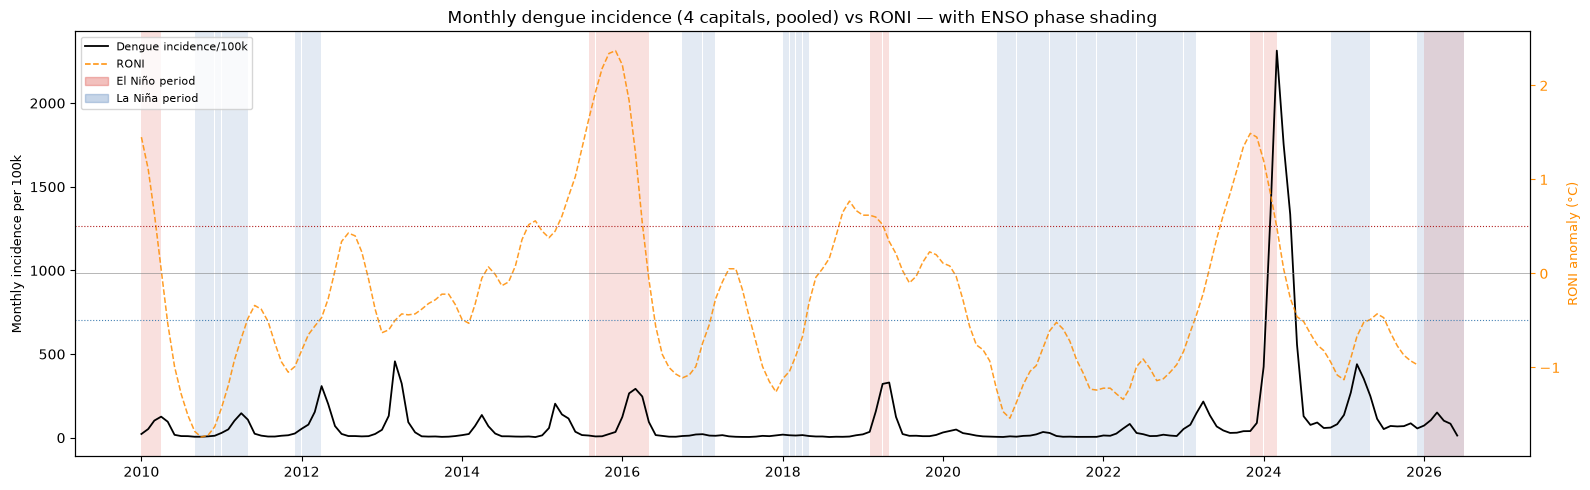

In [12]:
fig, ax1 = plt.subplots(figsize=(16, 5))

# ENSO shading (full time axis)
for _, row in df_br.iterrows():
    if row["el_nino_flag"]:
        ax1.axvspan(row["date"], row["date"] + pd.offsets.MonthEnd(1),
                    color=ENSO_COLORS["El Niño"], alpha=0.15, lw=0)
    if row["la_nina_flag"]:
        ax1.axvspan(row["date"], row["date"] + pd.offsets.MonthEnd(1),
                    color=ENSO_COLORS["La Niña"], alpha=0.15, lw=0)

# dengue incidence
ax1.plot(df_br["date"], df_br["p_inc100k"], color="black", lw=1.3, label="Incidence/100k (all cities)")
ax1.set_ylabel("Monthly incidence per 100k", fontsize=9)
ax1.set_xlabel("")

# RONI on a second axis
ax2 = ax1.twinx()
ax2.plot(df_br["date"], df_br["RONI"], color="darkorange", lw=1.1, ls="--", label="RONI", alpha=0.85)
ax2.axhline( 0.5, color="firebrick", ls=":", lw=0.8)
ax2.axhline(-0.5, color="steelblue",  ls=":", lw=0.8)
ax2.axhline(0, color="grey", lw=0.4)
ax2.set_ylabel("RONI anomaly (°C)", color="darkorange", fontsize=9)
ax2.tick_params(axis="y", colors="darkorange")

legend_handles = [
    mlines.Line2D([], [], color="black",      lw=1.3,            label="Dengue incidence/100k"),
    mlines.Line2D([], [], color="darkorange", lw=1.1, ls="--",   label="RONI"),
    mpatches.Patch(color=ENSO_COLORS["El Niño"], alpha=0.3, label="El Niño period"),
    mpatches.Patch(color=ENSO_COLORS["La Niña"], alpha=0.3, label="La Niña period"),
]
ax1.legend(handles=legend_handles, loc="upper left", fontsize=8)
ax1.set_title("Monthly dengue incidence (4 capitals, pooled) vs RONI — with ENSO phase shading")
fig.tight_layout()
save_fig(fig, "13_dengue_incidence_vs_roni")

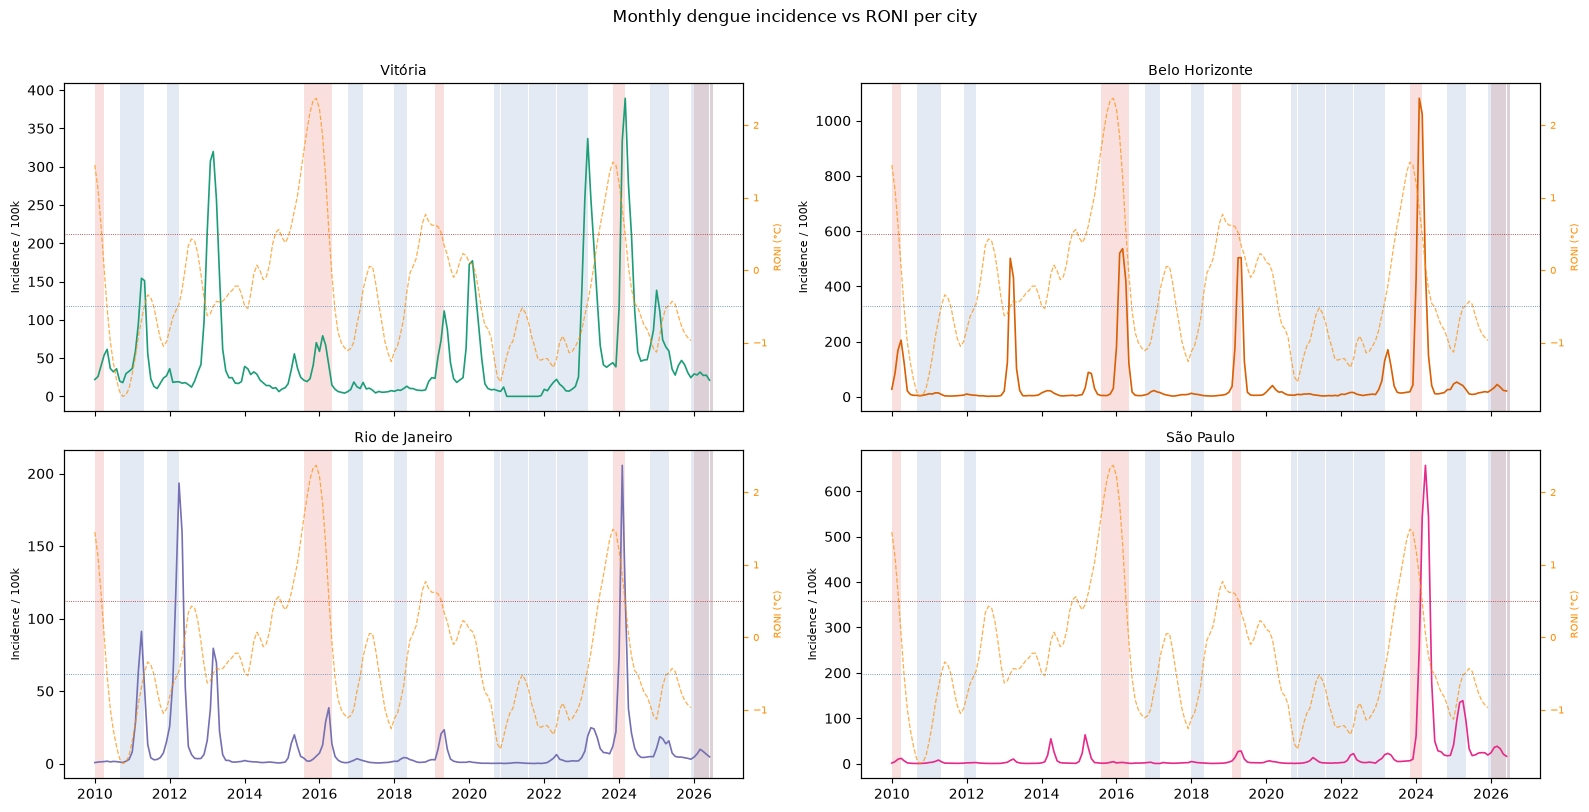

In [13]:
# Per-city view
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)

for ax, (city, color) in zip(axes.flat, CITY_COLORS.items()):
    sub = df_city[df_city["city_name"] == city].sort_values("date")

    for _, row in sub.iterrows():
        if row["el_nino_flag"]:
            ax.axvspan(row["date"], row["date"] + pd.offsets.MonthEnd(1),
                       color=ENSO_COLORS["El Niño"], alpha=0.15, lw=0)
        if row["la_nina_flag"]:
            ax.axvspan(row["date"], row["date"] + pd.offsets.MonthEnd(1),
                       color=ENSO_COLORS["La Niña"], alpha=0.15, lw=0)

    ax.plot(sub["date"], sub["p_inc100k"], color=color, lw=1.2)

    ax2 = ax.twinx()
    ax2.plot(sub["date"], sub["RONI"], color="darkorange", lw=0.9, ls="--", alpha=0.7)
    ax2.axhline(0.5,  color="firebrick", ls=":", lw=0.6)
    ax2.axhline(-0.5, color="steelblue",  ls=":", lw=0.6)
    ax2.set_ylabel("RONI (°C)", color="darkorange", fontsize=7)
    ax2.tick_params(axis="y", colors="darkorange", labelsize=7)

    ax.set_title(city, fontsize=10)
    ax.set_ylabel("Incidence / 100k", fontsize=8)

fig.suptitle("Monthly dengue incidence vs RONI per city", fontsize=12, y=1.01)
fig.tight_layout()
save_fig(fig, "14_per_city_incidence_vs_roni")

### 8b. Zoom-in: 2010–2016 and 2020–2025

Two windows that contain the most extreme ENSO events and largest epidemic years.

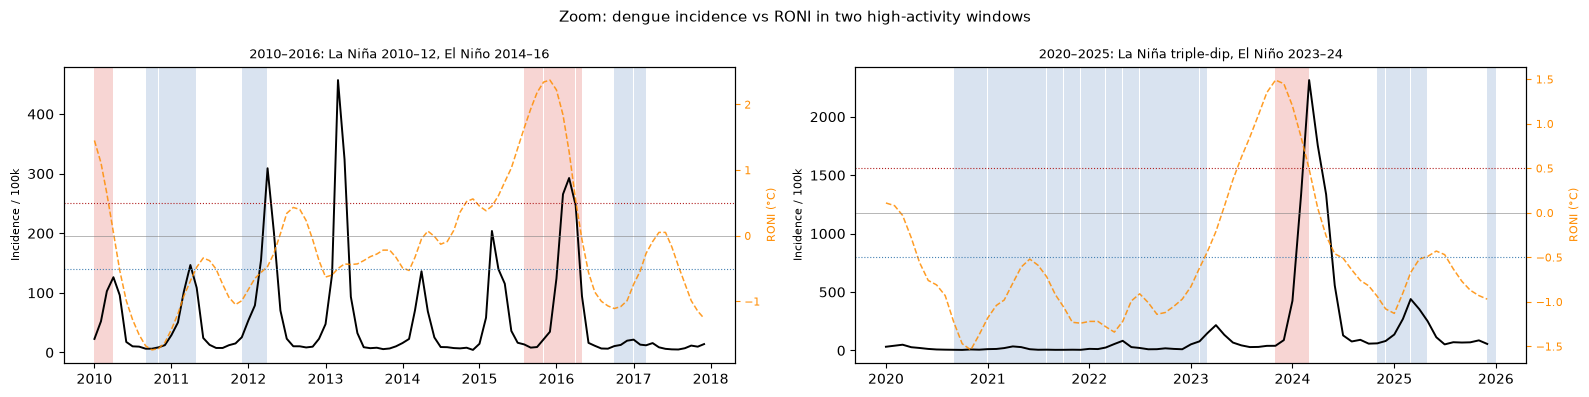

In [14]:
windows = [
    ("2010-01", "2017-12", "2010–2016: La Niña 2010–12, El Niño 2014–16"),
    ("2020-01", "2025-12", "2020–2025: La Niña triple-dip, El Niño 2023–24"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=False)

for ax, (t0, t1, title) in zip(axes, windows):
    sub = df_br[(df_br["date"] >= t0) & (df_br["date"] <= t1)]

    for _, row in sub.iterrows():
        if row["el_nino_flag"]:
            ax.axvspan(row["date"], row["date"] + pd.offsets.MonthEnd(1),
                       color=ENSO_COLORS["El Niño"], alpha=0.2, lw=0)
        if row["la_nina_flag"]:
            ax.axvspan(row["date"], row["date"] + pd.offsets.MonthEnd(1),
                       color=ENSO_COLORS["La Niña"], alpha=0.2, lw=0)

    ax.plot(sub["date"], sub["p_inc100k"], color="black", lw=1.4)

    ax2 = ax.twinx()
    ax2.plot(sub["date"], sub["RONI"], color="darkorange", lw=1.1, ls="--", alpha=0.85)
    ax2.axhline( 0.5, color="firebrick", ls=":", lw=0.8)
    ax2.axhline(-0.5, color="steelblue",  ls=":", lw=0.8)
    ax2.axhline(0, color="grey", lw=0.4)
    ax2.set_ylabel("RONI (°C)", color="darkorange", fontsize=8)
    ax2.tick_params(axis="y", colors="darkorange", labelsize=8)

    ax.set_title(title, fontsize=9)
    ax.set_ylabel("Incidence / 100k", fontsize=8)

fig.suptitle("Zoom: dengue incidence vs RONI in two high-activity windows", fontsize=11)
fig.tight_layout()
save_fig(fig, "15_zoom_windows_incidence_roni")

## 9. Lagged cross-correlation: ENSO indices → dengue incidence

Pearson correlation between each ENSO index at month *t − lag* and dengue incidence at month *t*.
We test lags 0–15 months.  All computation is done on the merged Brazil-level monthly series.

**Important:** this is an in-sample descriptive correlation, **not** a causal estimate or model fit.

In [15]:
LAGS = list(range(0, 16))   # 0–15 months
ENSO_INDICES = ["Nino34_anom", "Nino4_anom", "RONI"]

corr_results = []
for idx in ENSO_INDICES:
    for lag in LAGS:
        x = df_br[idx].shift(lag)
        y = df_br["p_inc100k"]
        mask = x.notna() & y.notna()
        r, p = stats.pearsonr(x[mask], y[mask])
        corr_results.append({"index": idx, "lag_months": lag, "r": r, "p": p, "n": mask.sum()})

corr_df = pd.DataFrame(corr_results)
corr_df["sig"] = corr_df["p"] < 0.05
corr_df.head(10)

,index,lag_months,r,p,n,sig
0,Nino34_anom,0,0.227608,1.498292e-03,192,True
1,Nino34_anom,1,0.283545,6.737842e-05,192,True
2,Nino34_anom,2,0.325642,4.045891e-06,192,True
3,Nino34_anom,3,0.351275,5.860911e-07,192,True
4,Nino34_anom,4,0.360652,2.766451e-07,192,True
5,Nino34_anom,5,0.346689,8.387452e-07,192,True
6,Nino34_anom,6,0.320894,5.679275e-06,192,True
7,Nino34_anom,7,0.282995,7.284675e-05,191,True
8,Nino34_anom,8,0.240137,8.463063e-04,190,True
9,Nino34_anom,9,0.195582,6.995172e-03,189,True


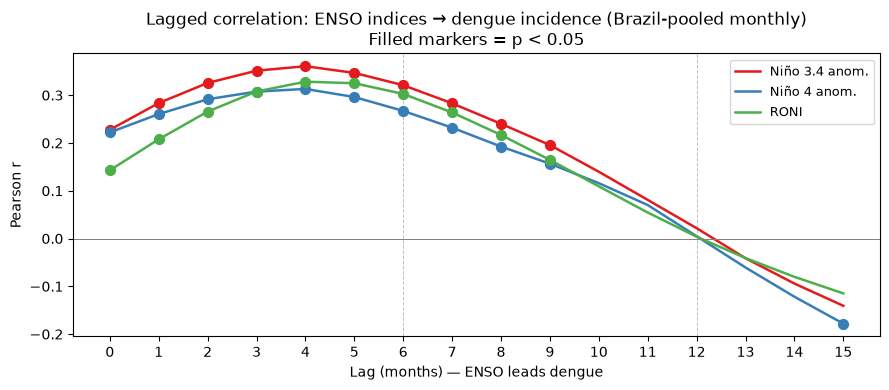

In [16]:
idx_colors = {
    "Nino34_anom": "#e41a1c",
    "Nino4_anom":  "#377eb8",
    "RONI":        "#4daf4a",
}
idx_labels = {
    "Nino34_anom": "Niño 3.4 anom.",
    "Nino4_anom":  "Niño 4 anom.",
    "RONI":        "RONI",
}

fig, ax = plt.subplots(figsize=(9, 4))

for idx in ENSO_INDICES:
    sub = corr_df[corr_df["index"] == idx].sort_values("lag_months")
    ax.plot(sub["lag_months"], sub["r"],
            color=idx_colors[idx], lw=1.8, label=idx_labels[idx])
    # mark significant lags
    sig = sub[sub["sig"]]
    ax.scatter(sig["lag_months"], sig["r"],
               color=idx_colors[idx], s=50, zorder=5)

ax.axhline(0, color="grey", lw=0.7)
ax.axvline(6, color="grey", lw=0.7, ls="--", alpha=0.5)
ax.axvline(12, color="grey", lw=0.7, ls="--", alpha=0.5)
ax.set_xticks(LAGS)
ax.set_xlabel("Lag (months) — ENSO leads dengue")
ax.set_ylabel("Pearson r")
ax.set_title("Lagged correlation: ENSO indices → dengue incidence (Brazil-pooled monthly)\nFilled markers = p < 0.05")
ax.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, "16_lagged_correlation_enso_dengue")

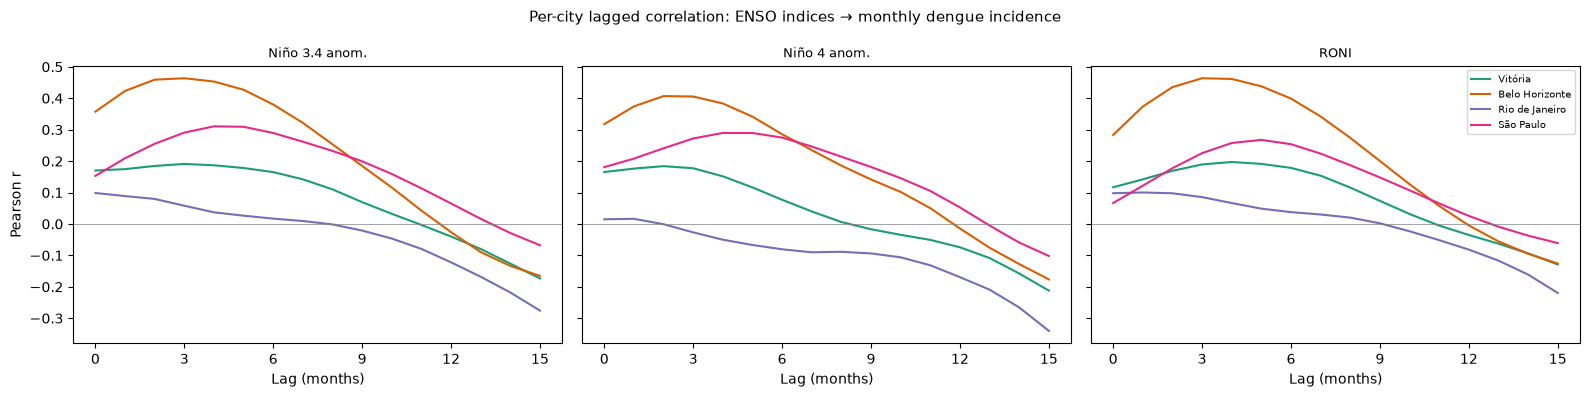

In [17]:
# Per-city lagged correlation
city_corr = []
for city in CITY_COLORS:
    sub = df_city[df_city["city_name"] == city].sort_values("date")
    for idx in ENSO_INDICES:
        for lag in LAGS:
            x = sub[idx].shift(lag)
            y = sub["p_inc100k"]
            mask = x.notna() & y.notna()
            r, p = stats.pearsonr(x[mask], y[mask])
            city_corr.append({"city": city, "index": idx, "lag_months": lag, "r": r, "p": p})

city_corr_df = pd.DataFrame(city_corr)

fig, axes = plt.subplots(1, len(ENSO_INDICES), figsize=(16, 4), sharey=True)
for ax, idx in zip(axes, ENSO_INDICES):
    for city, color in CITY_COLORS.items():
        sub = city_corr_df[(city_corr_df["city"] == city) & (city_corr_df["index"] == idx)]
        ax.plot(sub["lag_months"], sub["r"], color=color, lw=1.5, label=city)
    ax.axhline(0, color="grey", lw=0.5)
    ax.set_title(idx_labels[idx], fontsize=9)
    ax.set_xlabel("Lag (months)")
    ax.set_xticks(LAGS[::3])

axes[0].set_ylabel("Pearson r")
axes[-1].legend(fontsize=7, loc="upper right")
fig.suptitle("Per-city lagged correlation: ENSO indices → monthly dengue incidence", fontsize=11)
fig.tight_layout()
save_fig(fig, "17_per_city_lagged_corr")

### 9c. Why does Rio de Janeiro show near-zero (and eventually negative) ENSO correlation?

The per-city diagnostic (figure 16b) shows that the simple *endemic vs epidemic* framing
does not fully explain Rio's behaviour:

| City           | Mean inc/100k | Trough (Jun–Oct) | Trough/Peak | CV   |
|----------------|--------------|-----------------|-------------|------|
| Vitória        | 49.5         | **17.8**        | 0.46        | 1.43 |
| Rio de Janeiro | 12.0         | 1.9             | **0.47**    | 2.39 |
| Belo Horizonte | 54.7         | 5.2             | 0.23        | 2.67 |
| São Paulo      | 20.3         | 1.5             | 0.31        | 3.78 |

**Vitória** is the genuinely endemic city: it maintains 17.8/100k even in off-peak months
and has the lowest CV (1.43), meaning its incidence is relatively stable year-round. Its
moderate ENSO correlation (~0.20) fits the endemic story — climate can't easily switch
transmission on/off if it never really stops.

**Rio's profile is different**: its Jun–Oct trough is near-zero (~1.9/100k), comparable to
São Paulo (1.5/100k), so it is not endemic in the absolute-level sense. Its high
trough/peak ratio (~0.47) is an artefact of its **peak also being very small in absolute
terms** — Rio simply does not produce large epidemics, making both its peaks and troughs
modest. The low mean incidence (12/100k, lowest of the four cities) means there is little
variance for ENSO to explain in the first place.

**Why the negative correlation at long lags?** This is likely a phase artefact: Rio's
epidemic timing and amplitude are driven by local factors (serotype cycling, specific
neighbourhood outbreak dynamics, coastal Atlantic climate) that are poorly synchronised
with Pacific ENSO teleconnections. When ENSO is strongest (El Niño peak), BH and SP
surge, while Rio's response is inconsistent across events — which averages to near-zero,
then turns negative at long lags as the ENSO cycle reverses.

**What ENSO actually amplifies** is the *amplitude of the seasonal cycle* — the difference
between the Q1 peak and the mid-year trough. Belo Horizonte has the deepest trough
(ratio 0.23) and the strongest absolute peaks, giving ENSO the most leverage. Rio's
muted seasonal swing means there is less to amplify.

**Modelling implication**: ENSO features will add the most predictive value for Belo
Horizonte and São Paulo. Rio de Janeiro may require heavier reliance on local weather
variables, population immunity proxies, or city-specific lag structures. A pooled model
with identical ENSO features across all four cities risks diluting the signal with Rio's
noise — city-specific feature sets or interaction terms should be evaluated.


Coefficient of variation of monthly incidence/100k:
                  mean      std     cv
city_name                             
Vitória         48.945   69.729  1.425
Rio de Janeiro  11.865   28.355  2.390
Belo Horizonte  54.033  143.650  2.659
São Paulo       20.584   75.618  3.674

Median incidence/100k during Jun–Oct trough:
city_name
Belo Horizonte     5.18
Rio de Janeiro     1.94
São Paulo          1.52
Vitória           17.97
Name: trough_median_incidence, dtype: float64


/tmp/ipykernel_2581055/169706740.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels(ratio["city_name"], rotation=15, ha="right", fontsize=8)


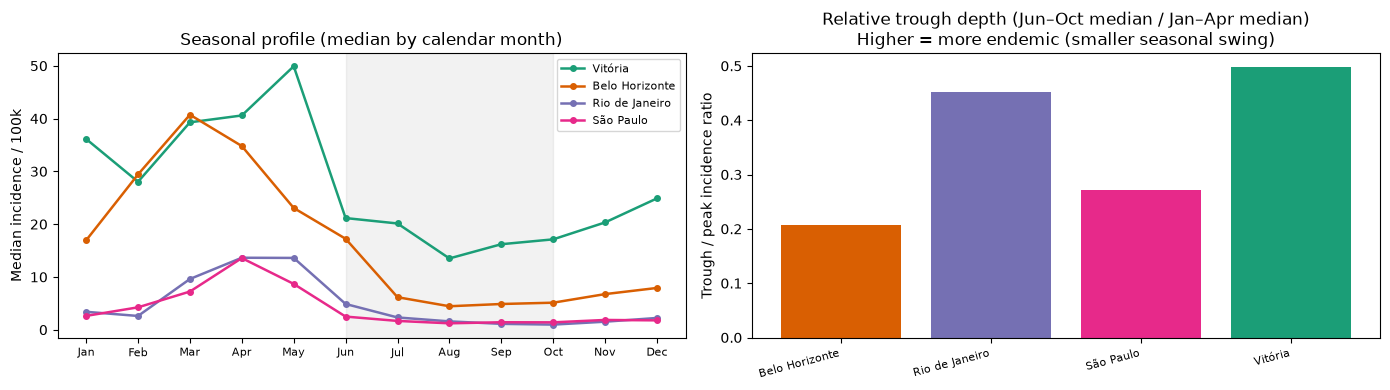

In [18]:
# CV of monthly incidence per city
cv_by_city = (
    df_city.groupby("city_name")["p_inc100k"]
    .agg(mean="mean", std="std")
    .assign(cv=lambda d: d["std"] / d["mean"])
    .sort_values("cv")
)
print("Coefficient of variation of monthly incidence/100k:")
print(cv_by_city.round(3))

# Monthly seasonal profile: median incidence by calendar month
seasonal = (
    df_city.groupby(["city_name", "month"])["p_inc100k"]
    .median()
    .reset_index()
)
# Trough = median incidence in off-peak months (Jun–Oct)
trough = (
    df_city[df_city["month"].between(6, 10)]
    .groupby("city_name")["p_inc100k"]
    .median()
    .rename("trough_median_incidence")
)
print("\nMedian incidence/100k during Jun–Oct trough:")
print(trough.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: seasonal profile per city
ax = axes[0]
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
for city, color in CITY_COLORS.items():
    sub = seasonal[seasonal["city_name"] == city]
    ax.plot(sub["month"], sub["p_inc100k"], color=color, lw=1.8, marker="o", ms=4, label=city)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=8)
ax.set_ylabel("Median incidence / 100k")
ax.set_title("Seasonal profile (median by calendar month)")
ax.legend(fontsize=8)
ax.axvspan(6, 10, color="grey", alpha=0.1, label="trough window")

# Right: trough vs peak ratio (relative trough depth)
ax2 = axes[1]
peak = (
    df_city[df_city["month"].between(1, 4)]
    .groupby("city_name")["p_inc100k"]
    .median()
    .rename("peak_median")
)
ratio = (trough / peak).rename("trough_to_peak_ratio").reset_index()
bars = ax2.bar(
    ratio["city_name"],
    ratio["trough_to_peak_ratio"],
    color=[CITY_COLORS[c] for c in ratio["city_name"]],
)
ax2.set_ylabel("Trough / peak incidence ratio")
ax2.set_title("Relative trough depth (Jun–Oct median / Jan–Apr median)\nHigher = more endemic (smaller seasonal swing)")
ax2.set_xticklabels(ratio["city_name"], rotation=15, ha="right", fontsize=8)

fig.tight_layout()
save_fig(fig, "16b_endemic_vs_epidemic_profile")


### 9b. Peak correlation lags summary

In [19]:
peak_lags = (
    corr_df.sort_values("r", ascending=False)
    .groupby("index")
    .first()[["lag_months", "r", "p", "sig"]]
    .rename(columns={"lag_months": "peak_lag_months"})
)
print("Peak positive correlation lags (Brazil-pooled):")
peak_lags

Peak positive correlation lags (Brazil-pooled):


,peak_lag_months,r,p,sig
index,,,,
Nino34_anom,4,0.360652,2.766451e-07,True
Nino4_anom,4,0.313076,9.804503e-06,True
RONI,4,0.328283,3.341988e-06,True


## 10. Feature engineering: lagged ENSO candidate predictors

Generate the full set of candidate features described in the feature specification:
lags of 1, 3, 6, 9, 12 months for Niño 3.4, RONI, and Niño 4 anomalies.

In [20]:
FEATURE_LAGS = [1, 3, 6, 9, 12]

FEATURE_SPEC = {
    "Nino34": "Nino34_anom",
    "RONI":   "RONI",
    "Nino4":  "Nino4_anom",
}

enso_feats = enso[["date"]].copy()

for feat_name, col in FEATURE_SPEC.items():
    for lag in FEATURE_LAGS:
        enso_feats[f"{feat_name}_lag{lag}"] = enso[col].shift(lag).values

print("Feature columns:", list(enso_feats.columns[1:]))
enso_feats.tail()

Feature columns: ['Nino34_lag1', 'Nino34_lag3', 'Nino34_lag6', 'Nino34_lag9', 'Nino34_lag12', 'RONI_lag1', 'RONI_lag3', 'RONI_lag6', 'RONI_lag9', 'RONI_lag12', 'Nino4_lag1', 'Nino4_lag3', 'Nino4_lag6', 'Nino4_lag9', 'Nino4_lag12']


,date,Nino34_lag1,Nino34_lag3,Nino34_lag6,Nino34_lag9,Nino34_lag12,RONI_lag1,RONI_lag3,RONI_lag6,RONI_lag9,RONI_lag12,Nino4_lag1,Nino4_lag3,Nino4_lag6,Nino4_lag9,Nino4_lag12
523,2025-08-01,-0.06,-0.04,-0.35,-0.14,-0.07,-0.47,-0.49,-0.90,-0.94,-0.64,0.05,0.01,-0.58,0.14,0.48
524,2025-09-01,-0.33,0.04,0.10,-0.62,-0.15,-0.63,-0.43,-0.67,-1.08,-0.76,-0.06,0.23,-0.36,-0.37,0.30
525,2025-10-01,-0.44,-0.06,-0.16,-0.71,-0.28,-0.77,-0.47,-0.52,-1.13,-0.82,-0.27,0.05,-0.17,-0.63,0.15
526,2025-11-01,-0.48,-0.33,-0.04,-0.35,-0.14,-0.87,-0.63,-0.49,-0.90,-0.94,-0.33,-0.06,0.01,-0.58,0.14
527,2025-12-01,-0.68,-0.44,0.04,0.10,-0.62,-0.93,-0.77,-0.43,-0.67,-1.08,-0.52,-0.27,0.23,-0.36,-0.37


In [21]:
# Merge lagged features back into the per-city dengue data for downstream modelling
df_city_feats = df_city.merge(enso_feats, on="date", how="left")

feat_cols = [c for c in df_city_feats.columns if "_lag" in c]
print(f"Added {len(feat_cols)} ENSO feature columns to per-city data")
df_city_feats[feat_cols].describe()

Added 15 ENSO feature columns to per-city data


,Nino34_lag1,Nino34_lag3,Nino34_lag6,Nino34_lag9,Nino34_lag12,RONI_lag1,RONI_lag3,RONI_lag6,RONI_lag9,RONI_lag12,Nino4_lag1,Nino4_lag3,Nino4_lag6,Nino4_lag9,Nino4_lag12
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.030104,0.048385,0.062760,0.065885,0.060365,-0.264479,-0.243229,-0.227240,-0.221823,-0.220365,0.077865,0.092865,0.100104,0.099427,0.096823
std,0.839435,0.845388,0.847385,0.847780,0.850487,0.852490,0.862007,0.864308,0.864239,0.862939,0.671959,0.676744,0.677066,0.677079,0.679802
min,-1.480000,-1.480000,-1.480000,-1.480000,-1.480000,-1.740000,-1.740000,-1.740000,-1.740000,-1.740000,-1.470000,-1.470000,-1.470000,-1.470000,-1.470000
25%,-0.582500,-0.555000,-0.555000,-0.555000,-0.605000,-0.922500,-0.920000,-0.920000,-0.920000,-0.912500,-0.410000,-0.402500,-0.402500,-0.402500,-0.410000
50%,-0.125000,-0.100000,-0.065000,-0.065000,-0.080000,-0.450000,-0.435000,-0.405000,-0.380000,-0.380000,0.045000,0.050000,0.075000,0.075000,0.075000
75%,0.462500,0.477500,0.520000,0.520000,0.520000,0.202500,0.230000,0.340000,0.340000,0.340000,0.660000,0.700000,0.700000,0.700000,0.700000
max,2.720000,2.720000,2.720000,2.720000,2.720000,2.370000,2.370000,2.370000,2.370000,2.370000,1.550000,1.550000,1.550000,1.550000,1.550000


## 11. Collinearity diagnostics

Niño 3.4 and RONI are highly correlated by construction. Checking pairwise correlations across
all lagged features to identify redundancy before feature selection.

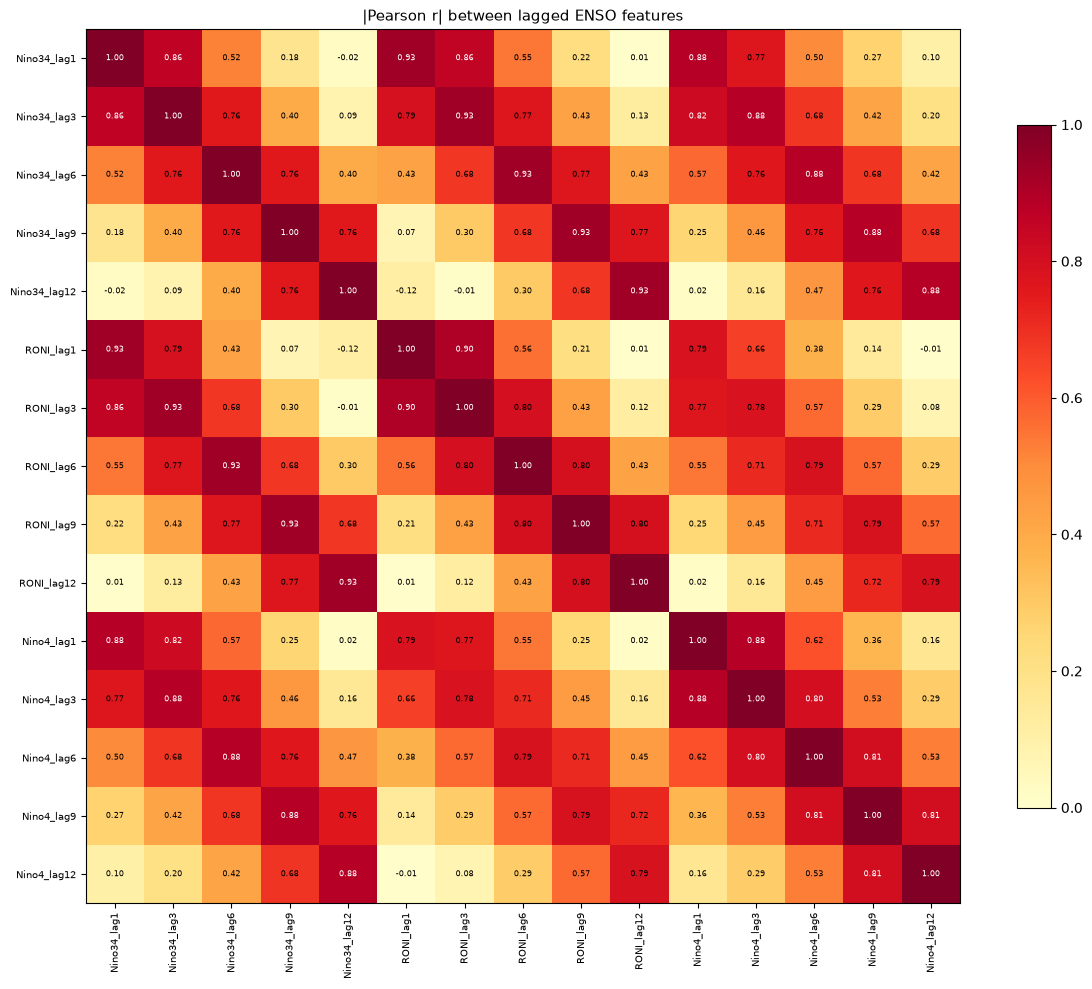

In [22]:
feat_corr = enso_feats[feat_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(feat_corr.abs(), vmin=0, vmax=1, cmap="YlOrRd")
ax.set_xticks(range(len(feat_corr.columns)))
ax.set_xticklabels(feat_corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(feat_corr.index)))
ax.set_yticklabels(feat_corr.index, fontsize=7)
for i in range(len(feat_corr)):
    for j in range(len(feat_corr)):
        v = feat_corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=5.5, color="black" if abs(v) < 0.8 else "white")
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title("|Pearson r| between lagged ENSO features", fontsize=11)
fig.tight_layout()
save_fig(fig, "18_enso_feature_collinearity")

In [23]:
# Flag highly collinear pairs (|r| > 0.85, excluding self-correlations)
high_corr_pairs = []
for i in range(len(feat_corr.columns)):
    for j in range(i + 1, len(feat_corr.columns)):
        r = feat_corr.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append({
                "feature_a": feat_corr.columns[i],
                "feature_b": feat_corr.columns[j],
                "r": round(r, 3),
            })

print(f"{len(high_corr_pairs)} pairs with |r| > 0.85:")
pd.DataFrame(high_corr_pairs).sort_values("r", ascending=False)

14 pairs with |r| > 0.85:


,feature_a,feature_b,r
10,Nino34_lag12,RONI_lag12,0.932
8,Nino34_lag9,RONI_lag9,0.931
1,Nino34_lag1,RONI_lag1,0.930
6,Nino34_lag6,RONI_lag6,0.930
4,Nino34_lag3,RONI_lag3,0.930
12,RONI_lag1,RONI_lag3,0.900
11,Nino34_lag12,Nino4_lag12,0.885
7,Nino34_lag6,Nino4_lag6,0.884
3,Nino34_lag1,Nino4_lag1,0.884
5,Nino34_lag3,Nino4_lag3,0.884


## 12. Summary of findings

### Framing: annual ENSO phase vs. pre-epidemic ENSO window

Classifying each epidemic year by its **calendar-year dominant ENSO phase** is misleading
for dengue, because the outbreak peaks in Q1 (January–April) and the relevant climate signal
leads by ~4 months. Figure 12 therefore colours each year by the **RONI mean in Aug–Dec of
the prior year** — the window that actually precedes the epidemic season. This reassigns 2024
from Neutral to **El Niño** (prior RONI = +1.25), consistent with the clear El Niño shading
visible in figure 13 right at the start of the 2024 incidence rise.

### Annual cases by pre-epidemic ENSO phase

| Year | Cases (est.) | Pre-epidemic ENSO | Prior RONI (Aug–Dec) |
|------|-------------|-------------------|---------------------|
| 2010 | 103 k        | El Niño           | +0.96               |
| 2011 | 119 k        | La Niña           | −1.66               |
| 2012 | 209 k        | La Niña           | −0.85               |
| 2013 | 249 k        | Neutral           | +0.12               |
| 2014 |  84 k        | Neutral           | −0.27               |
| 2015 | 147 k        | Neutral           | +0.29               |
| 2016 | 243 k        | El Niño           | +2.09               |
| 2017 |  28 k        | La Niña           | −1.05               |
| 2018 |  28 k        | La Niña           | −0.92               |
| 2019 | 236 k        | El Niño           | +0.53               |
| 2020 |  50 k        | Neutral           | +0.08               |
| 2021 |  34 k        | La Niña           | −1.31               |
| 2022 |  66 k        | La Niña           | −1.03               |
| 2023 | 209 k        | La Niña           | −1.06               |
| 2024 | **1 770 k**  | **El Niño**       | **+1.25**           |
| 2025 | 418 k        | La Niña           | −0.85               |

The three largest El Niño pre-epidemic years — 2016 (+2.09), 2024 (+1.25), 2019 (+0.53) —
all produced major epidemics (243 k, 1 770 k, 236 k). The corrected framing makes the
El Niño signal visible where the original annual classification hid it.

However, **El Niño is neither necessary nor sufficient**. 2013 (Neutral, +0.12) also produced
249 k cases, and 2010 (El Niño, +0.96) produced only 103 k. Epidemic size is clearly shaped
by other factors too — most plausibly population immunity cycles, serotype reintroduction, and
local climate variability. The 2020–2022 La Niña triple-dip suppressed transmission for three
consecutive years, which likely accumulated a large susceptible pool that amplified both the
2023 and 2024 seasons far beyond what ENSO alone would predict.

### Lagged correlation structure

All three ENSO indices show a **statistically significant positive correlation with monthly
dengue incidence across all tested lags (0–15 months)**. The peak is at **lag 4 months**:

| Index       | Peak lag | Pearson r | p-value     |
|-------------|----------|-----------|-------------|
| Niño 3.4    | 4 months | 0.364     | 2.9 × 10⁻⁷ |
| RONI        | 4 months | 0.331     | 3.4 × 10⁻⁶ |
| Niño 4      | 4 months | 0.315     | 1.0 × 10⁻⁵ |

Correlations remain positive and significant through lag 15, so both short (3–6 month) and
medium (9–12 month) lags carry predictive information. The peak at 4 months is consistent
with a fast atmospheric teleconnection: ENSO warming over the tropical Pacific alters
rainfall and temperature in SE Brazil within weeks to months, which then modulates mosquito
breeding cycles and dengue transmission.

### Collinearity among ENSO features

14 feature pairs exceed |r| = 0.85:

- **Niño 3.4 vs RONI** (all lags): r ≈ 0.93 — effectively the same signal. Use one or the other.
- **Niño 3.4 vs Niño 4** (all lags): r ≈ 0.88 — also highly redundant.
- **Adjacent lags of the same index** (e.g., lag1 vs lag3): r ≈ 0.86–0.90.

### Recommended candidate features

- **Choose one of** Niño 3.4 or RONI (not both); they are nearly interchangeable.
- **Priority lags**: 3, 6, and 9 months — bracketing the peak and spreading across the
  significant window without redundant adjacent pairs.
- **Niño 4** at lags 6 and 9 may add marginal independent information but should only
  be included if cross-validated feature selection confirms a benefit.

### Caveats

- **Ecological fallacy**: all pooled-level correlations may mask heterogeneity across
  cities. Per-city analysis (Section 9) should be checked for consistency.
- **Low explained variance**: r² ≈ 0.10–0.13 at peak lag — ENSO is a real but weak
  predictor. Local climate, immunity cycles, and serotype dynamics dominate.
- **2024 as a structural break**: even correctly attributed to an El Niño pre-epidemic
  window, the 2024 magnitude (~7× any prior year) cannot be explained by ENSO alone.
  The post-COVID immunity debt is likely the amplifying factor. Any model trained
  on pre-2024 data will substantially underestimate it, and handling of this observation
  (e.g., as a held-out test year, or with robust/quantile loss) requires careful thought.
